# Correlations between indices and ground truth



## 1. Load packages

In [221]:
# -*- coding: utf-8 -*-
"""
Updated 2 December 2025
Author: Sylvain Haupert
"""

from IPython import get_ipython
print(__doc__)

# Clear all the variables
get_ipython().run_line_magic('reset', '-sf')

# suppress all warnings
import warnings
warnings.filterwarnings("ignore")

# Import standard libraries
from pathlib import Path 
import matplotlib.pyplot as plt
import pandas as pd 
pd.options.display.float_format = "{:,.2f}".format # display numbers with 2 decimals
import os
import sys
import numpy as np
from scipy.stats import spearmanr
import seaborn as sns
from tqdm import tqdm

# Import maad package
from maad import util

# abspath = os.path.abspath(get_ipython().run_line_magic('pwd', ''))
# os.chdir(abspath + '/notebooks')

# Import custom statistical functions
sys.path.append(str(Path('./src')))
from stat_func import bootstrap_corr, permutation_corr

# Import configuration file
import config as cfg

# Close all the figures (like in Matlab)
plt.close("all")


Updated 2 December 2025
Author: Sylvain Haupert



## 2. Notebook init and options setting

* Select the annotation file
* Select the dataset to analyze

In [222]:
"""==============================================================================
       General options             
=============================================================================="""

# Set the options
SAVE = True
PROCESS = False
DISPLAY = True
VERBOSE = False

# Load the configuration file
CONFIG = cfg.load_config('config_local.yaml')

# Set the global variables
GT = CONFIG['ground_truth']
CORR_METHOD = CONFIG['correlation_method']
N_BOOT = CONFIG['n_bootstrap']
R_THRESHOLD = 0.3 # moderate correlation following Cohen's criteria

# initialize the list of indices, annotations and sites
BIRDNET_ALL = []
ANNOTATIONS_ALL = []
SITES_ALL = []

"""==============================================================================
       Prepare the configuration for each dataset
=============================================================================="""

# loop over the datasets to get the filenames of the indices and annotations and the selected sites corresponding to each dataset
for DATASET in CONFIG['datasets']:

       BIRDNET_ALL     += [(CONFIG['birdnet_predictions_filename'], os.path.dirname(DATASET['path']))] 
       ANNOTATIONS_ALL += [(CONFIG['annotations_filename'], os.path.dirname(DATASET['path']))] 
       SITES_ALL       += DATASET['sites']

       # display the dataset name
       print(f'Dataset {DATASET["name"]} is being preparing...')       
       # display the number of sites
       print(f'The dataset {DATASET["name"]} contains {len(DATASET["sites"])} sites \n')

"""==============================================================================
       Options for display     
=============================================================================="""

PALETTE_NAME = "Set2" 
NUM_COLORS = 7

# set a dictionnary with the color for each habitat
HABITAT_COLOR = {
       'Arable land': sns.color_palette(PALETTE_NAME, NUM_COLORS)[0],
       'Forest - Subtropical-tropical moist lowland': sns.color_palette(PALETTE_NAME, NUM_COLORS)[1],
       'Forest - Subtropical-tropical moist montane': sns.color_palette(PALETTE_NAME, NUM_COLORS)[2],
       'Plantations': sns.color_palette(PALETTE_NAME, NUM_COLORS)[3],
       'Forest - Temperate': sns.color_palette(PALETTE_NAME, NUM_COLORS)[4],
       'Shrubland - Subtropical-tropical high altitude': sns.color_palette(PALETTE_NAME, NUM_COLORS)[5],
       'Shrubland - Temperate': sns.color_palette(PALETTE_NAME, NUM_COLORS)[6],
       }

# Get the default palette
RED     = sns.color_palette('Set1')[0]
BLUE    = sns.color_palette('Set1')[1]
GREEN   = sns.color_palette('Set1')[2]


Dataset sapsucker_woods is being preparing...
The dataset sapsucker_woods contains 1 sites 

Dataset bialowieza is being preparing...
The dataset bialowieza contains 15 sites 

Dataset hawai is being preparing...
The dataset hawai contains 2 sites 

Dataset coffee_farms is being preparing...
The dataset coffee_farms contains 2 sites 

Dataset usa_sierra_nevada_forest is being preparing...
The dataset usa_sierra_nevada_forest contains 33 sites 

Dataset uk_sussex_countryside is being preparing...
The dataset uk_sussex_countryside contains 45 sites 

Dataset ecuador is being preparing...
The dataset ecuador contains 45 sites 

Dataset risoux is being preparing...
The dataset risoux contains 1 sites 

Dataset peru is being preparing...
The dataset peru contains 7 sites 



## 3. Preparation of the dataframe df

* Open and read dataframes with indices (variables) and with labels (ground truth)
* Clean and merge both dataframes

### 3.1 Clean, merge and save the dataframe with all the data

* Indices where previously calculated with scikit-maad package (V1.5.1) on Python.
* Manual annotations are coming from different datasets that belong to very different projects. They were formated to be readable in the same way.

> Indices and manual annotations are merged into a single dataframe. Some variables are renamed while others are dropped because we do not want to analyse them. The final dataframe is saved for further analyses, for instance in R.

In [214]:
"""==============================================================================
    Dataframe creation
    ------------------

    Summary of the steps:
    ---------------------
    - Load all the CSV files containing the acoustic indices and the annotations
    - Select only the sites of interest in each dataset
    - Prepare the dataset with indices and the dataset with annotations
    - Merge the two dataframes into a single one
    - Display some information about the merged dataframe
    - Save the dataframe for further analysis in Python or R

=============================================================================="""
# LOAD CSV
df_birdnet = pd.DataFrame()
for birdnet_parquet, birdnet_dir in BIRDNET_ALL:
    try:
        print(f"Loading {os.path.join(birdnet_dir, birdnet_parquet)}")
        df_temp = pd.read_parquet(os.path.join(birdnet_dir, birdnet_parquet))
        print("The number of rows in the dataframe is {}".format(len(df_temp)))
        df_temp["dataset"] = birdnet_dir.split("/")[-1]
        df_birdnet = pd.concat([df_birdnet, df_temp], axis=0)
    except:
        print(f"Error : {os.path.join(birdnet_dir, birdnet_parquet)} does not exist")
    

df_label = pd.DataFrame()
for annotations_csv, annotations_dir in ANNOTATIONS_ALL:
    try:
        df_temp = pd.read_csv(os.path.join(annotations_dir, annotations_csv), sep=",")
        df_temp["dataset"] = annotations_dir.split("/")[-1]
        df_label = pd.concat([df_label, df_temp], axis=0)
    except:
        print(
            f"Error : {os.path.join(annotations_dir, annotations_csv)} does not exist"
        )

# select a site
df_label = df_label[df_label["site"].isin(SITES_ALL)]

print("The total intial number of files is {}".format(len(df_label)))

# prepare the birdnet predictions dataframe

# keep only the columns 'filename', 'predicted_species', 'confidence'
df_birdnet = df_birdnet[["filename", "predicted_species", "confidence"]]

# Group by date and filename, and concatenate the lists in predicted_species and confidence columns
df_birdnet = df_birdnet.groupby(["filename"]).agg(
    {
        "predicted_species": lambda x: [item for sublist in x for item in sublist],
        "confidence": lambda x: [item for sublist in x for item in sublist],
    }
)

# reset the index
df_birdnet.reset_index(inplace=True)

# filter each list in the predicted_species and confidence based on the corresponding confidence list, keeping only species with confidence >= THRESHOLD (0.1)

df_birdnet['predicted_species_filtered'] = df_birdnet.apply(
    lambda row: [species for species, conf in zip(row['predicted_species'], row['confidence']) if conf >= CONFIG['confidence_threshold'] ], axis=1
)
df_birdnet['confidence_filtered'] = df_birdnet.apply(
    lambda row: [conf for species, conf in zip(row['predicted_species'], row['confidence']) if conf >= CONFIG['confidence_threshold']], axis=1
)

# remove no detection in the predicted_species_filtered list
df_birdnet['predicted_species_filtered'] = df_birdnet['predicted_species_filtered'].apply(lambda x: [species for species in x if species != 'no detection'])

# add a column with the number of unique species in the predicted_species_filtered list
df_birdnet['birdnet_species_richness'] = df_birdnet['predicted_species_filtered'].apply(lambda x: len(set(x)))

# keep only the columns 'filename', birdnet_species_richness
df_birdnet = df_birdnet[['filename','birdnet_species_richness']]

# set index
df_birdnet.set_index("filename", inplace=True)
df_label.set_index("filename", inplace=True)

# keep several columns
# df_label = df_label[[ 'date', 'site', 'LAT', 'LON', 'device_id', 'biome', 'dataset', 'species_richness']]
df_label = df_label[
    ["date", "site", "device_id", "biome", "dataset", "species_richness"]
]

# Rename the column biome into habitat
df_label = df_label.rename(columns={"biome": "habitat"})

# HACK
df_label["species_richness"] = df_label["species_richness"].astype("float")
# transform the values into float
df_birdnet = df_birdnet.select_dtypes(include=['number']).astype('float')

# Create a new df by merging df_birdnet and df_label
df = pd.merge(df_birdnet, df_label, on='filename', how='inner')

# display the number of files per dataset
for dataset in CONFIG['datasets'] :
    print(f'The number of files for the dataset {dataset["name"]} is {len(df[df["site"].isin(dataset["sites"])])}')

# display the number of files per habitat and the number of sites per habitat
print('\n')
for habitat in df['habitat'].unique() :
    print(f'The number of files for the habitat {habitat} is {len(df[df["habitat"] == habitat])}')
    print(f'The number of sites for the habitat {habitat} is {len(df[df["habitat"] == habitat]["site"].unique())} \n')


Loading ../data/USA_Sapsucker/birdnet_predictions.parquet


The number of rows in the dataframe is 10880
Loading ../data/Bialowieza/birdnet_predictions.parquet
Error : ../data/Bialowieza/birdnet_predictions.parquet does not exist
Loading ../data/Hawai/birdnet_predictions.parquet
The number of rows in the dataframe is 7140
Loading ../data/Coffee_farms/birdnet_predictions.parquet
The number of rows in the dataframe is 2240
Loading ../data/USA_sierra_nevada_forest/birdnet_predictions.parquet
The number of rows in the dataframe is 2640
Loading ../data/UK_Sussex_countryside/birdnet_predictions.parquet
The number of rows in the dataframe is 40069
Loading ../data/Ecuador/birdnet_predictions.parquet
The number of rows in the dataframe is 13500
Loading ../data/dB@risoux/birdnet_predictions.parquet
The number of rows in the dataframe is 1160
Loading ../data/Peru/birdnet_predictions.parquet
The number of rows in the dataframe is 1680
Error : ../data/Bialowieza/species_gt_15min.csv does not exist
The total intial number of files is 4619
The number of files

## 4. Analysis

### 4.1. Spearman correlation between indices and richness, habitat by habitat


************ Arable land **************
Number of points : 632 
Correlation coefficient with species_richness and indices: 
birdnet_species_richness   0.58
Name: species_richness, dtype: float64
************ Forest - Subtropical-tropical moist lowland **************
Number of points : 309 
Correlation coefficient with species_richness and indices: 
Series([], Name: species_richness, dtype: float64)
************ Forest - Subtropical-tropical moist montane **************
Number of points : 355 
Correlation coefficient with species_richness and indices: 
Series([], Name: species_richness, dtype: float64)
************ Forest - Temperate **************
Number of points : 1409 
Correlation coefficient with species_richness and indices: 
Series([], Name: species_richness, dtype: float64)
************ Plantations **************
Number of points : 337 
Correlation coefficient with species_richness and indices: 
Series([], Name: species_richness, dtype: float64)
************ Shrubland - Subtropi

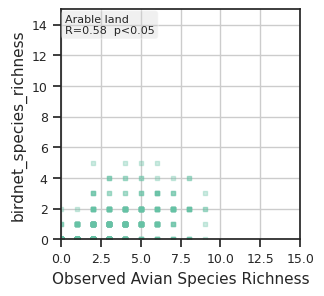

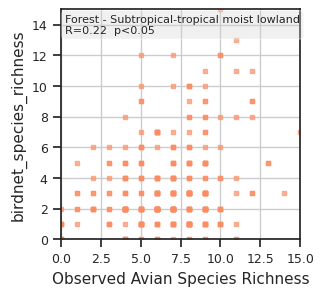

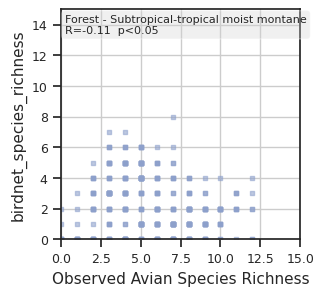

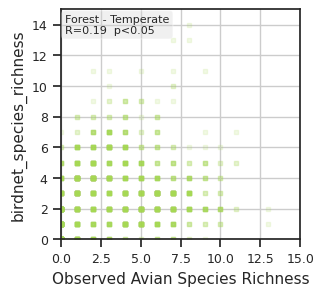

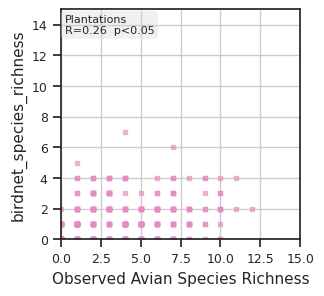

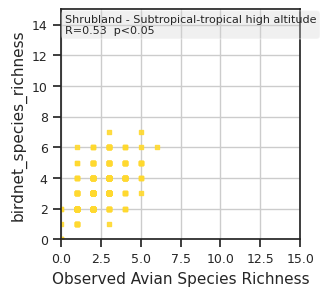

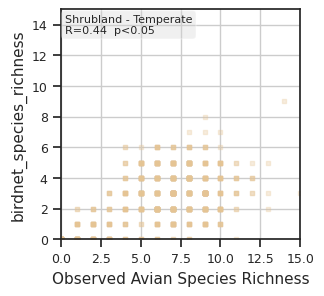

In [215]:
"""==============================================================================
        CORRELATION BETWEEN INDICES AND RICHNESS
        ----------------------------------------

        Summary of the steps:
        ---------------------
        - Select the index to display
        - Select the ground truth => species_richness
        - For each habitat
                - Compute the spearman correlation 
                - Display the scatter plot between the index and the ground truth
                - Save the figure

=============================================================================="""

# select the index to display
INDICE = 'birdnet_species_richness' 

# Set the label of the ground truth (x label)
if GT == 'species_richness' :
        GT_LABEL = 'Observed Avian Species Richness'
elif GT == 'species_abundance' :
        GT_LABEL = 'Species abundance'
else :
        GT_LABEL = GT

sns.set_theme(style="whitegrid")
sns.set_style("ticks")

# sort the column habitat to have the same automatic color assignation
df = df.sort_values(by='habitat')

for HABITAT in df['habitat'].unique() :

        # select the habitat
        subdf = df[df['habitat'] == HABITAT]

        print('************ ' + HABITAT +' **************')
        print("Number of points : {} ".format(len(subdf)))

        # Compute the correlation matrix
        corr_matrix = subdf.select_dtypes(include=['number']).corr(CORR_METHOD)
        best_corr_with_richness = corr_matrix[GT].loc[abs(corr_matrix[GT])>R_THRESHOLD]
        
        print("Correlation coefficient with {} and indices: \n{}".format(GT, best_corr_with_richness.sort_values()[:-1]))

        ############ p value #############
        if CORR_METHOD == 'spearman' :
                pval = spearmanr(subdf[INDICE], subdf[GT])[1]
        
        if pval >= 0.05 :
                pval_str = 'p=%.2f' % pval
        else:
                pval_str = 'p<0.05'

        ############ RICHNESS ###########
        fig, ax1 = plt.subplots(1, 1)
        # Set figure size
        fig.set_size_inches((3.25,3))
        fig.tight_layout()

        # Display the correlation graphic between the indice and the ground truth
        ##### SCATTER PLOT
        ax1.scatter(subdf[GT], subdf[INDICE],   alpha=min(1,200/len(subdf)), s=10,  marker = 's' , color=HABITAT_COLOR[HABITAT])
        ax1.grid()
        ax1.set_xlabel(GT_LABEL, fontdict={'size': 11})
        ax1.set_ylabel(INDICE, fontdict={'size': 11})
        ax1.set_xlim([df[GT].min(),df[GT].max()])
        ax1.set_ylim([df[INDICE].min(),df[INDICE].max()])
        ax1.annotate(
                "%s\nR=%.2f  %s" % (HABITAT, corr_matrix[GT][INDICE], pval_str), 
                xy=(0.018, 0.895), 
                xycoords='axes fraction', 
                fontsize = 8,
                bbox=dict(
                        facecolor='lightgrey', 
                        alpha = 0.33,
                        edgecolor='white', 
                        boxstyle='round')
                )
        # change font size of the x and y-axis tick labels
        ax1.tick_params(axis='x', labelsize=9)
        ax1.tick_params(axis='y', labelsize=9)

        # if SAVE : fig.savefig(os.path.join(CONFIG['save_dir'], 'figure_2_'+HABITAT+'_'+INDICE +'_vs_'+GT+'_onlybirds.png'), dpi = 300, bbox_inches = "tight")

Additional information about sites for each habitat :
- the total number of sites and files per habitat
- the site with the lowest number of files per habitat

### 4.2. Spearman correlation between indices and richness, with all balanced habitats

The minimum number of samples is for the habitat Shrubland - Subtropical-tropical high altitude and the number is 227


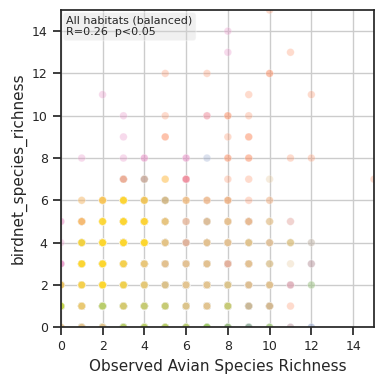

In [216]:
"""==============================================================================
        CORRELATION BETWEEN INDICES AND RICHNESS
        ----------------------------------------

        Summary of the steps:
        --------------------
        - Select the acoustic index (INDICE) => nROI
        - Select the ground truth (GT) => species_richness
        - Balance the dataset by habitat:
                - Find habitat with minimum sample count
                - Sample equal number of observations from each habitat
        - Save the balanced dataset to CSV
        - Compute correlation matrix using specified method (i.e. spearman)
        - Filter correlations above threshold (R_THRESHOLD)
        - Calculate p-value for statistical significance
        - Create the correlation plot between the selected index and ground truth:
                - Color points by habitat
                - Display correlation coefficient and p-value
        - Save the correlation plot figure

=============================================================================="""

INDICE = 'birdnet_species_richness' # 

# Set the label of the ground truth (x label)
if GT == 'species_richness' :
        GT_LABEL = 'Observed Avian Species Richness'
elif GT == 'species_abundance' :
        GT_LABEL = 'Species abundance'
else :
        GT_LABEL = GT

"""--------------------------------------------------------------
        Create a balanced dataset : same sampling by habitat.
--------------------------------------------------------------"""

# Group the DataFrame by 'habitat' and count the number of rows in each group
habitat_counts = df['habitat'].value_counts()

# Find the habitat with the minimum number of rows
min_habitat = habitat_counts.idxmin()
min_row_count = habitat_counts.min()

print("The minimum number of samples is for the habitat {} and the number is {}".format(min_habitat, min_row_count))

# Create an empty DataFrame to store the sampled data
sampled_df = pd.DataFrame(columns=df.columns)

# Iterate through each habitat and sample the minimum rows
for habitat, group in df.groupby('habitat'):
        sampled_rows = group.sample(n=min_row_count, random_state=CONFIG['seed'])  # Use a specific random_state for reproducibility
        sampled_df = pd.concat([sampled_df, sampled_rows])

# # save the sampled dataframe
# if SAVE :
#         if CONFIG['remove_clipping_audio'] :
#                 sampled_df.to_csv(path_or_buf=os.path.join(CONFIG['save_dir'], 'data_species_balanced_sans_clip_onlybirds.csv'), sep=',', mode='w', header=True, index=True)
#         else :
#                 sampled_df.to_csv(path_or_buf=os.path.join(CONFIG['save_dir'], 'data_species_balanced_onlybirds.csv'), sep=',', mode='w', header=True, index=True)

"""------------------------------
        Correlation.
--------------------------------"""

# set the R threshold to R_THRESHOLD
corr_matrix = sampled_df.select_dtypes(include=['number']).corr(CONFIG['correlation_method'])

# p value
if CORR_METHOD == 'spearman' :
        pval = spearmanr(sampled_df[INDICE], sampled_df[GT])[1]

if pval >= 0.05 :
        pval_str = 'p=%.2f' % pval
else:
        pval_str = 'p<0.05'

"""------------------------------
        Display.
--------------------------------"""
# Display the correlation graphic between the indice and the ground truth
fig, ax1 = plt.subplots(1, 1)

# SCATTER PLOT
sampled_df = sampled_df.sort_values(by='habitat')

# set the palette with the color of the habitats
sns.set_theme(style="whitegrid", palette=HABITAT_COLOR.values())
sns.set_style("ticks")

sns.scatterplot(data=sampled_df, x=GT, y=INDICE, hue='habitat', alpha=min(1,500/len(sampled_df)), s=30,  marker = 'o' , ax=ax1, legend=False)
ax1.grid()
ax1.set_xlim([sampled_df[GT].min(),sampled_df[GT].max()])
ax1.set_ylim([sampled_df[INDICE].min(),sampled_df[INDICE].max()])
ax1.set_xlabel(GT_LABEL, fontdict={'size': 11})
ax1.set_ylabel(INDICE, fontdict={'size': 11})
ax1.annotate(
        "All habitats (balanced)\nR=%.2f  %s" % (corr_matrix[GT][INDICE], pval_str), 
        xy=(0.018, 0.92), 
        xycoords='axes fraction', 
        fontsize = 8,
        bbox=dict(
                facecolor='lightgrey', 
                alpha = 0.33,
                edgecolor='white', 
                boxstyle='round')
        )
# change font size of the x and y-axis tick labels
ax1.tick_params(axis='x', labelsize=9)
ax1.tick_params(axis='y', labelsize=9)

# # Set figure size
fig.set_size_inches((4,4))
fig.tight_layout()

# if SAVE : fig.savefig(os.path.join(CONFIG['save_dir'], 'figure_2_All_balanced_onlybirds.png'), dpi = 300, bbox_inches = "tight")

### 4.7 Correlation between average values per site

In [217]:
"""===============================================================================
    Group data and compute the correlation the indice and the ground truth
    ----------------------------------------------------------------------

    Summary of the steps:
    ---------------------
    - Group data by 'site' and calculate mean for numeric columns
    - Filter out sites with less than 3 samples
    - Compute correlation matrix using specified method (i.e. spearman)
    - Filter correlations above threshold (R_THRESHOLD=0.3)
    - Map habitat information to grouped data for futher use
    - Save the grouped data to CSV

================================================================================"""

# Use the groupby method to group by the 'site' column
grouped = df.groupby('site')

# Filter numeric columns
numeric_columns = df.select_dtypes(include=[int, float])

# Group by 'site' and calculate the mean for each numeric column
df_count= grouped[numeric_columns.columns].count()
df_mean = grouped[numeric_columns.columns].mean()
df_std  = grouped[numeric_columns.columns].std()

# add a count column to keep the nummber of 1min audio files by site
df_mean['count'] = df_count.iloc[:,0]

""" -----------------------------------------------------
    remove sites with count less than 3 sampling effort
-------------------------------------------------------"""
print(f"The number of sites before filtering is {df_mean.shape[0]}")
df_mean = df_mean[df_mean['count']>=3]
print(f"The number of sites after filtering is {df_mean.shape[0]}")

corr_matrix = df_mean.select_dtypes(include=['number']).corr(CONFIG['correlation_method'])
best_corr = corr_matrix[GT].loc[abs(corr_matrix[GT])>R_THRESHOLD]

print("Correlation coefficient with {} and indices: \n{}".format(GT, best_corr.sort_values()[:-1]))

# Create a dictionary from 'df' with 'site' as keys and 'habitat' as values
site_to_habitat = df.set_index('site')['habitat'].to_dict()
# Map the 'habitat' values to df_mean based on 'site'
df_mean['habitat'] = (df_mean.reset_index()['site'].map(site_to_habitat)).to_list()
# Reset the index 'site'
df_mean.reset_index(inplace=True)

# if SAVE : 
#     if CONFIG['remove_clipping_audio'] :
#         df_mean.to_csv(path_or_buf=os.path.join(CONFIG['save_dir'], GT+"_by_site_sans_clip_onlybirds.csv"), sep=',', mode='w', header=True, index=False)
#     else :
#         df_mean.to_csv(path_or_buf=os.path.join(CONFIG['save_dir'], GT+"_by_site_onlybirds.csv"), sep=',', mode='w', header=True, index=False)

The number of sites before filtering is 136
The number of sites after filtering is 136
Correlation coefficient with species_richness and indices: 
count   0.30
Name: species_richness, dtype: float64


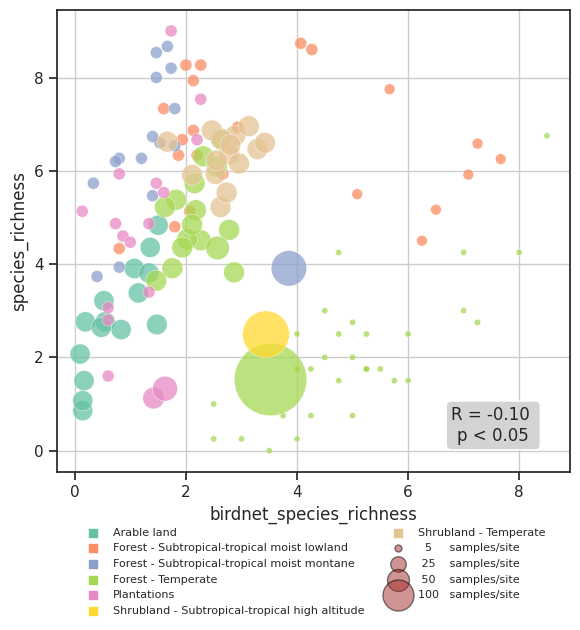

In [218]:
"""===============================================================================
        Display correlation  between the indice and the ground truth
        ------------------------------------------------------------

        Summary of the steps:
        ---------------------
        - Using the grouped data by site
        - Select the acoustic index (INDICE) => nROI
        - Select the ground truth (GT) => species_richness
        - Display the correlation plot between the selected index and ground truth:
                - Marker size by number of samples per site
                - Color points by habitat
                - Display correlation coefficient and p-value
        - Save the correlation plot figure

==============================================================================="""

INDICE_TO_DISPLAY = 'birdnet_species_richness' 

# Display the correlation graphic between the indice and the ground truth
fig, ax1 = plt.subplots(1, 1)

# sort the column habitat to have the same automatic color assignation
df_mean = df_mean.sort_values(by='habitat')
# marker size
# extact the column count from df_mean_by_day, and multiply the values (scalar) by 5
marker_size = df_mean['count'].values*5

# display the scatterplot
sns.set_theme(style="whitegrid")
sns.set_style("ticks")
sns.scatterplot(data=df_mean, x=INDICE_TO_DISPLAY, y=GT, 
                hue='habitat', s=marker_size, alpha=0.75,
                palette=HABITAT_COLOR,
                ax=ax1, legend=False)

ax1.grid()
ax1.set_ylabel(INDICE_TO_DISPLAY)
ax1.set_ylabel(GT)
ax1.annotate(
        "R = %.2f \np < 0.05" % (corr_matrix[GT][INDICE_TO_DISPLAY]), 
        xy=(0.85, 0.1), 
        xycoords='axes fraction', 
        ha='center', 
        va='center', 
        bbox=dict(
                facecolor='lightgrey', 
                edgecolor='white', 
                boxstyle='round')
        )

# add a legend with fixed marker size for each habitat and its corresponding color
for HABITAT in df_mean['habitat'].unique():
        ax1.scatter([], [], c=HABITAT_COLOR[HABITAT], label=HABITAT, marker='s', s=40)

# add bubble size legend
bubble_sizes = [5, 25, 50, 100]
bubble_labels = ['  5     samples/site', ' 25    samples/site', ' 50    samples/site', '100   samples/site']
for size, label in zip(bubble_sizes, bubble_labels):
        ax1.scatter([], [], c='brown', edgecolor='black', alpha=0.5, s=size*5, label=label)


# Move the legend to the bottom
ax1.legend(title="habitat", loc="upper left", fontsize=8)
sns.move_legend(ax1, "upper center", bbox_to_anchor=(.5, -0.1), ncol=2, title=None, frameon=False, fontsize=8)

# Set figure size
fig.set_size_inches((6,6.5))
fig.tight_layout()


### 4.8 Correlation between average values per day par site


In [219]:
"""===============================================================================
    Group data and compute the correlation the indice and the ground truth
    ----------------------------------------------------------------------

    Summary of the steps:
    ---------------------
    - Group data by 'site' and 'day' and calculate mean for numeric columns
    - Filter out site-days with less than 3 samples
    - Compute correlation matrix using specified method (i.e. spearman)
    - Filter correlations above threshold (R_THRESHOLD=0.3)
    - Map habitat information to grouped data for futher use
    - Save the grouped data to CSV
    
================================================================================"""

# convert the column date into datetime
df['date'] = pd.to_datetime(df['date'])

# extract the string %YY%MM%DD from the date
df['day'] =  df['date'].dt.strftime('%Y-%m-%d')

# Use the groupby method to group by the 'site' and 'day' column
grouped = df.groupby(['site','day'])

# Filter numeric columns
numeric_columns = df.select_dtypes(include=[int, float])

# Group by 'site'  and 'day' and calculate the mean for each numeric column
df_count_by_day = grouped[numeric_columns.columns].count()
df_mean_by_day = grouped[numeric_columns.columns].mean()
df_std_by_day  = grouped[numeric_columns.columns].std()

# add a count column to keep the nummber of 1min audio files by day and site
df_mean_by_day['count'] = df_count_by_day.iloc[:,0]

""" ==========================================================
    remove day with count less than 3 Sampling effort
=============================================================="""
print(f"The number of samples before filtering is {df_mean_by_day.shape[0]}")
df_mean_by_day = df_mean_by_day[df_mean_by_day['count']>=3]
print(f"The number of samples after filtering is {df_mean_by_day.shape[0]}")

corr_matrix = df_mean_by_day.select_dtypes(include=['number']).corr(CONFIG['correlation_method'])
best_corr = corr_matrix[GT].loc[abs(corr_matrix[GT])>R_THRESHOLD]

print("Correlation coefficient with {} and indices: \n{}".format(GT, best_corr.sort_values()[:-1]))

# Create a dictionary from 'df' with 'site' as keys and 'habitat' as values
site_to_habitat = df.set_index('site')['habitat'].to_dict()
# Map the 'habitat' values to df_mean_by_day based on 'site'
df_mean_by_day['habitat'] = (df_mean_by_day.reset_index()['site'].map(site_to_habitat)).to_list()
# Reset the index 'site'
df_mean_by_day.reset_index(inplace=True)

# if SAVE : 
#     if CONFIG['remove_clipping_audio'] :
#         df_mean_by_day.to_csv(path_or_buf=os.path.join(CONFIG['save_dir'], GT+"_by_site_and_day_sans_clip_onlybirds.csv"), sep=',', mode='w', header=True, index=False)
#     else :
#         df_mean_by_day.to_csv(path_or_buf=os.path.join(CONFIG['save_dir'], GT+"_by_site_and_day_onlybirds.csv"), sep=',', mode='w', header=True, index=False)

The number of samples before filtering is 387
The number of samples after filtering is 379
Correlation coefficient with species_richness and indices: 
Series([], Name: species_richness, dtype: float64)


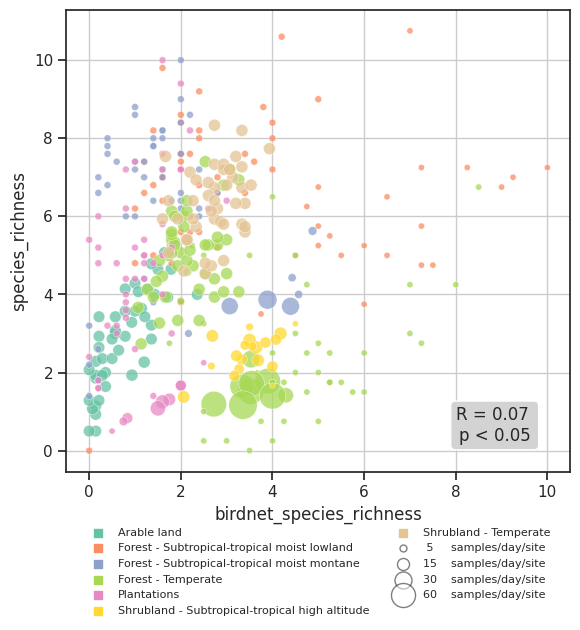

In [220]:
"""===============================================================================
        Display correlation  between the indice and the ground truth
        ------------------------------------------------------------

        Summary of the steps:
        ---------------------
        - Using the grouped data by site and day
        - Select the acoustic index (INDICE) => nROI
        - Select the ground truth (GT) => species_richness
        - Display the correlation plot between the selected index and ground truth:
                - Marker size by number of samples per site and day
                - Color points by habitat
                - Display correlation coefficient and p-value
        - Save the correlation plot figure
        
==============================================================================="""

INDICE_TO_DISPLAY = 'birdnet_species_richness' # nROI, aROI, NP, MFC BI, ACTspCount, EAS, ECU

# Display the correlation graphic between the indice and the ground truth
fig, ax1 = plt.subplots(1, 1)

# sort the column habitat to have the same automatic color assignation
df_mean_by_day = df_mean_by_day.sort_values(by='habitat')

# marker size
# extact the column count from df_mean_by_day, and multiply the values (scalar) by 5
marker_size = df_mean_by_day['count'].values*5

# display the scatterplot
sns.set_theme(style="whitegrid")
sns.set_style("ticks")
sns.scatterplot(data=df_mean_by_day, x=INDICE_TO_DISPLAY, y=GT, 
                hue='habitat', s=marker_size, alpha=0.75,
                palette=HABITAT_COLOR,
                ax=ax1, legend=False)

ax1.grid()
ax1.set_ylabel(INDICE_TO_DISPLAY)
ax1.set_ylabel(GT)
ax1.annotate(
        "R = %.2f \np < 0.05" % (corr_matrix[GT][INDICE_TO_DISPLAY]), 
        xy=(0.85, 0.1), 
        xycoords='axes fraction', 
        ha='center', 
        va='center', 
        bbox=dict(
                facecolor='lightgrey', 
                edgecolor='white', 
                boxstyle='round')
        )

# add a legend with fixed marker size for each habitat and its corresponding color
for HABITAT in df_mean_by_day['habitat'].unique():
        ax1.scatter([], [], c=HABITAT_COLOR[HABITAT], label=HABITAT, marker='s', s=40)

# add bubble size legend
bubble_sizes = [5, 15, 30, 60]
bubble_labels = [' 5     samples/day/site', '15    samples/day/site', '30    samples/day/site', '60    samples/day/site']
for size, label in zip(bubble_sizes, bubble_labels):
        ax1.scatter([], [], c='white', edgecolor='black', alpha=0.5, s=size*5, label=label)


# Move the legend to the bottom
ax1.legend(title="habitat", loc="upper left", fontsize=8)
sns.move_legend(ax1, "upper center", bbox_to_anchor=(.5, -0.1), ncol=2, title=None, frameon=False, fontsize=8)

# Set figure size
fig.set_size_inches((6,6.5))
fig.tight_layout()
